
# 🏷️ Logistic Regression

Aquest notebook mostra un exemple d'us del model de classificació **Logistic Regression**.

---

## 🎯 Objectius
-

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from google.colab import drive
drive.mount('/content/drive')
import os as os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Forma de la funció sigmoide

- the ***sigmoid function*** is defined as: $f\left(x\right)=\frac{1}{1 +\,\exp{\left(-x\right)}}$

In [43]:
import numpy as np
x = np.linspace(-5, 5, 1000)

In [44]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

y_prob = sigmoide(x)

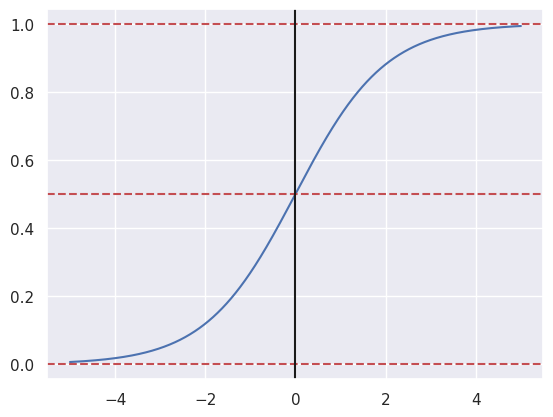

In [45]:
plt.plot(x, y_prob)
plt.axhline(0, c = 'r', linestyle = '--')
plt.axhline(0.5, c = 'r', linestyle = '--')
plt.axhline(1, c = 'r', linestyle = '--')
plt.axvline(0, c = 'k', linestyle = '-')

### Exemple:
 Volem predir si una persona compraria una assegurança de vida en funció de la seva edat

In [46]:
import pandas as pd

In [47]:

os.chdir('/content/drive/MyDrive/Colab Notebooks/M0572-SistemesAprenentatgeAutomatic/02_models_supervisats/')
p = os.getcwd()
#print(p)

sns.set_theme() # Setting seaborn style
df = pd.read_csv("dataset/insurance_data.csv")

df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


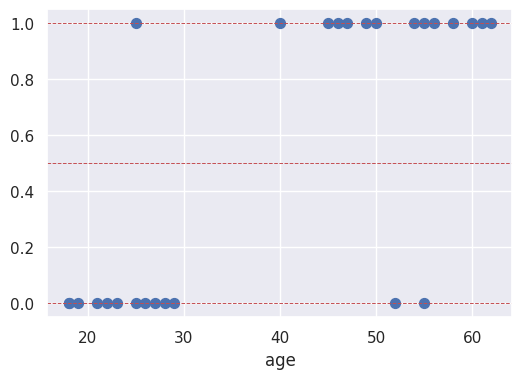

In [72]:
_, axs = plt.subplots(1, 1, figsize = (6, 4))
#axs.scatter(df.age, df.bought_insurance, marker = '+', s = 50, color = 'b')
axs.scatter(df.age, df.bought_insurance, s = 50, color = 'b')
plt.axhline(0, c = 'r', linestyle = '--', linewidth = 0.7)
plt.axhline(0.5, c = 'r', linestyle = '--', linewidth = 0.7)
plt.axhline(1, c = 'r', linestyle = '--', linewidth = 0.7)
axs.set_xlabel('age');

#### Construcció del model

Internament la Regessió Logística  - internally, the logistic regression es realitza mitjançan dos passo:

    1. Primer fem el model de regressió lineal.
$$y_{\text{linear}} = \beta_0 + \beta_1\, x_{\text{linear}}$$
    
    2. Segon, apliquem la funció sigmoid al resultat, it maps the result   
$$y_{logistic}=\frac{1}{1 +\exp\left(-y_{linear}\right)}=\frac{1}{1 +\exp{\left(-\left(\beta_0+\beta_1\,x_{linear}\right)\right)}}$$

In [49]:
from sklearn.linear_model import LogisticRegression

# independent variable
X = df.age.to_numpy().reshape(-1, 1)
# dependent variable
y = df.bought_insurance

X

array([[22],
       [25],
       [47],
       [52],
       [46],
       [56],
       [55],
       [60],
       [62],
       [61],
       [18],
       [28],
       [27],
       [29],
       [49],
       [55],
       [25],
       [58],
       [19],
       [18],
       [21],
       [26],
       [40],
       [45],
       [50],
       [54],
       [23]])

In [50]:
model = LogisticRegression().fit(X, y)

In [51]:
# Coeficient
print('\u03B21: %.5f' % model.coef_.item())
# Intercept (x = 0)
print('\u03B20: %.5f' % model.intercept_.item())
# error
print('R^2:', model.score(X, y))

β1: 0.13547
β0: -5.26279
R^2: 0.8888888888888888


- Ara podem predir la probabilitat de comprar l'assegurança de vida donada una edat.

In [52]:
model.predict(np.array([[65]]))

array([1])

- Podem visualitzar el model realitzan predicions donades unes edats. Per exemple de 0 a 100.

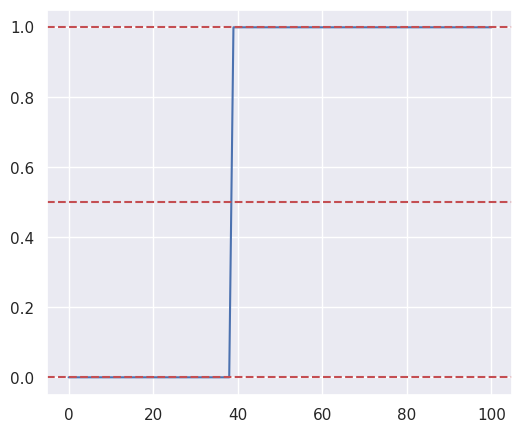

In [53]:
X = np.linspace(0, 100, 101).reshape(-1, 1)
Y = model.predict(X)
#
_, axs = plt.subplots(1, 1, figsize = (6, 5))
axs.plot(X, Y)
axs.axhline(0, c = 'r', linestyle = '--')
axs.axhline(0.5, c = 'r', linestyle = '--')
axs.axhline(1, c = 'r', linestyle = '--')

- El punt d'inflexio és el valor de l'edat on la probabilitat té un valor de 0.5

In [73]:
X = np.linspace(0, 100, 101).reshape(-1, 1)
Y = model.predict(X)
punt_inflexio = np.where(Y <= 0.5)[0][-1]
punt_inflexio

np.int64(38)

In [76]:
# La probabilitat canvia abruptment de 0 a 1
# Augmentem la precessió per trobar un punt d'inflexió més precís.
X = np.linspace(0, 100, 10000).reshape(-1, 1)
Y = model.predict(X)
punt_inflexio = np.where(Y <= 0.5)[0][-1]
punt_inflexio

np.int64(3884)

In [77]:
print('El punt d\'inflexió és a l''edat de  %5.2f for which the probability is %6.4f' %(X.flatten()[punt_inflexio], Y[punt_inflexio]))

El punt d'inflexió és a ledat de  38.84 for which the probability is 0.0000


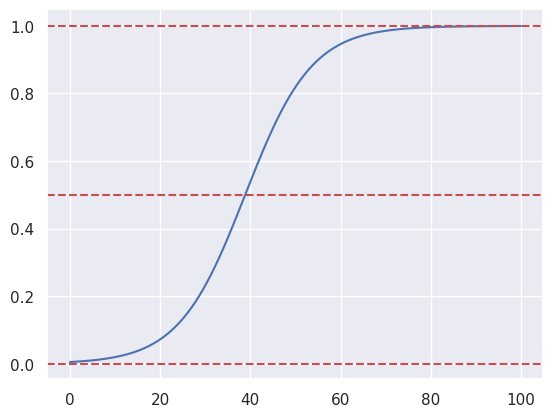

In [79]:
X = np.linspace(0, 100, 10000).reshape(-1, 1)

y_linear = model.intercept_.item() + model.coef_.item() * X
# Passem els valor de y_lineal per la probabilitat
y_prob = sigmoide(y_linear)

plt.plot(X, y_prob)
plt.axhline(0, c = 'r', linestyle = '--')
plt.axhline(0.5, c = 'r', linestyle = '--')
plt.axhline(1, c = 'r', linestyle = '--')
